In [5]:
from pathlib import Path
from PIL import Image
import piexif
import sys
sys.path.append('../src')

from visualization.telemetry import TelemetrySequence
from visualization.viewer import HyperlapseViewer, TrajectoryMapGenerator

hyperlapse_path = Path('../examples/sample_hyperlapse')
OUTPUT_DIR = '../data/outputs'

sample_img = hyperlapse_path / 'IMG_0000.jpg'
if sample_img.exists():
    img = Image.open(sample_img)
    exif = img.info.get('exif')
    if exif:
        data = piexif.load(exif)
        import pprint
        pprint.pprint(data)
    else:
        print('No EXIF data found')
else:
    print(f'Sample image not available: {sample_img}')

{'0th': {271: b'DJI',
         272: b'Mini 4 Pro',
         274: 1,
         305: b'DJI Fly 1.5.0',
         306: b'2026:03:12 16:33:18',
         34665: 143,
         34853: 212},
 '1st': {},
 'Exif': {36867: b'2026:03:12 16:33:18', 42035: b'DJI', 42036: b'Mini 4 Pro'},
 'GPS': {1: b'N',
         2: ((46, 1), (48, 1), (5003, 100)),
         3: b'W',
         4: ((71, 1), (12, 1), (2879, 100)),
         5: 0,
         6: (4892, 100)},
 'Interop': {},
 'thumbnail': None}


## Inspect EXIF Metadata

Show raw EXIF information from one of the sample images to verify structure.

In [7]:
if hyperlapse_path.exists() and telemetry:
    import pandas as pd
    
    # Create dataframe from telemetry
    data = []
    for i, telem in enumerate(telem_seq.telemetry[:10]):
        gps = telem.get('gps', {})
        data.append({
            'Image#': telem.get('index'),
            'Latitude': gps.get('latitude', 'N/A'),
            'Longitude': gps.get('longitude', 'N/A'),
            'Altitude(m)': gps.get('altitude', 'N/A'),
            'Drone': telem.get('drone_model', 'Unknown')
        })
    
    df = pd.DataFrame(data)
    display(df)

,Image#,Latitude,Longitude,Altitude(m),Drone
0,0,46.813897,-71.207997,48.92,DJI
1,1,46.813897,-71.207997,48.92,DJI
2,2,46.814000,-71.207997,51.04,DJI
3,3,46.814000,-71.207997,51.04,DJI
4,4,46.814097,-71.207997,51.17,DJI
5,5,46.814097,-71.207997,51.17,DJI
6,6,46.814197,-71.207997,49.58,DJI
7,7,46.814197,-71.207997,49.58,DJI
8,8,46.814297,-71.207997,50.30,DJI
9,9,46.814297,-71.207997,50.30,DJI


## Sample Telemetry Data

Display telemetry from first few images:

In [11]:
if hyperlapse_path.exists() and telemetry:
    # Reload module to get latest changes
    import importlib
    import visualization.viewer
    importlib.reload(visualization.viewer)
    from visualization.viewer import TrajectoryMapGenerator
    
    # Create output directory
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    
    # Generate maps
    print("Generating maps...")
    map_gen = TrajectoryMapGenerator(telem_seq)
    
    # Create trajectory map
    map_path = Path(OUTPUT_DIR) / 'trajectory_map.html'
    map_gen.create_trajectory_map(str(map_path))
    print(f"✓ Trajectory map: {map_path}")
    
    # Create altitude profile
    profile_path = Path(OUTPUT_DIR) / 'altitude_profile.png'
    map_gen.create_altitude_profile(str(profile_path))
    print(f"✓ Altitude profile: {profile_path}")
    
    # Display altitude profile
    if profile_path.exists():
        print("\n📊 Altitude Profile:")
        display(IPImage(str(profile_path)))
else:
    print("Extract telemetry first")

Extract telemetry first


In [ ]:
if hyperlapse_path.exists() and telemetry:
    # Reload module to get latest changes
    import importlib
    import visualization.viewer
    importlib.reload(visualization.viewer)
    from visualization.viewer import TrajectoryMapGenerator
    
    # Create output directory
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    
    # Generate maps
    print("Generating maps...")
    map_gen = TrajectoryMapGenerator(telem_seq)
    
    # Create trajectory map
    map_path = Path(OUTPUT_DIR) / 'trajectory_map.html'
    map_gen.create_trajectory_map(str(map_path))
    print(f"✓ Trajectory map: {map_path}")
    
    # Create altitude profile
    profile_path = Path(OUTPUT_DIR) / 'altitude_profile.png'
    map_gen.create_altitude_profile(str(profile_path))
    print(f"✓ Altitude profile: {profile_path}")
    
    # Display altitude profile
    if profile_path.exists():
        print("\n📊 Altitude Profile:")
        display(IPImage(str(profile_path)))
else:
    print("Extract telemetry first")

## Generate Maps and Reports

Create interactive maps and altitude profile:

C:\Users\41409\AppData\Local\Temp\ipykernel_3188\547980184.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


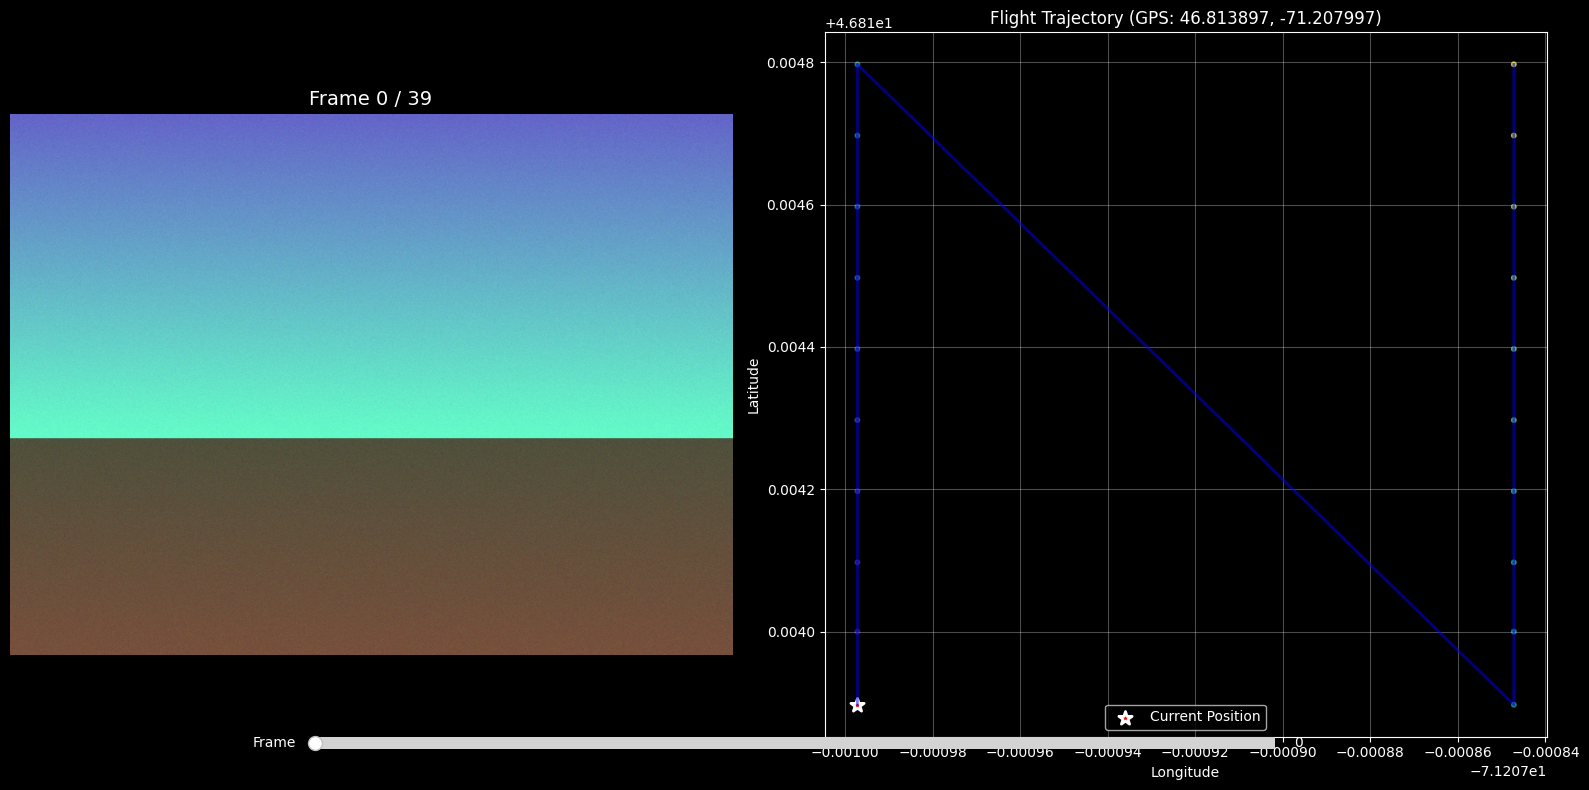

✓ Use slider to browse images


In [20]:
if hyperlapse_path.exists() and telemetry:
    # Reload module to get latest changes
    import importlib
    import visualization.viewer
    importlib.reload(visualization.viewer)
    from visualization.viewer import HyperlapseViewer
    
    viewer = HyperlapseViewer(str(hyperlapse_path), telem_seq)
    
    # Create figure for interactive viewing
    fig, (ax_main, ax_mini) = plt.subplots(1, 2, figsize=(16, 8))
    
    def update_image(index):
        """Update displayed image and telemetry"""
        ax_main.clear()
        ax_mini.clear()
        
        # Get image and telemetry
        img = viewer.get_image_at_index(index)
        telem = viewer.get_telemetry_at_index(index)
        
        if img is None:
            ax_main.text(0.5, 0.5, 'No image data', ha='center', va='center')
            return
        
        # Draw main image with telemetry overlay
        if telem:
            # img_with_overlay = viewer.draw_telemetry_overlay(img, telem)
            img_with_overlay = img  # Skip overlay for now
        else:
            img_with_overlay = img
        
        ax_main.imshow(img_with_overlay)
        ax_main.set_title(f'Frame {index} / {viewer.get_image_count()-1}', fontsize=14)
        ax_main.axis('off')
        
        # Draw minimap
        if telem and telem.get('gps'):
            gps = telem['gps']
            trajectory = telem_seq.get_trajectory()
            bounds = telem_seq.get_bounds()
            
            # Plot trajectory
            lats = [pt[0] for pt in trajectory]
            lons = [pt[1] for pt in trajectory]
            ax_mini.plot(lons, lats, 'b-', alpha=0.5, linewidth=2)
            
            # Plot all points
            ax_mini.scatter(lons, lats, c=range(len(lats)), cmap='viridis', s=10, alpha=0.5)
            
            # Highlight current position
            ax_mini.scatter(gps['longitude'], gps['latitude'], c='red', s=100, marker='*', 
                          edgecolors='white', linewidth=2, label='Current Position')
            
            ax_mini.set_xlabel('Longitude')
            ax_mini.set_ylabel('Latitude')
            ax_mini.set_title(f'Flight Trajectory (GPS: {gps["latitude"]:.6f}, {gps["longitude"]:.6f})')
            ax_mini.grid(True, alpha=0.3)
            ax_mini.legend()
        
        plt.tight_layout()
    
    # Create slider
    slider_ax = plt.axes([0.2, 0.05, 0.6, 0.03])
    slider = Slider(slider_ax, 'Frame', 0, viewer.get_image_count()-1, 
                   valinit=0, valstep=1, color='cyan')
    
    def on_slider_change(val):
        index = int(slider.val)
        update_image(index)
        fig.canvas.draw_idle()
    
    slider.on_changed(on_slider_change)
    
    # Show initial image
    update_image(0)
    plt.show()
    
    print("✓ Use slider to browse images")
    
else:
    print("Extract telemetry first")

## Interactive Image Viewer with Telemetry

Use the slider to browse images with overlaid GPS, altitude, and gimbal data:

In [17]:
if hyperlapse_path.exists():
    print(f"Path exists: {hyperlapse_path}")
    print("Extracting telemetry from images...")
    telem_seq = TelemetrySequence(str(hyperlapse_path))
    telemetry = telem_seq.extract_telemetry()
    
    print(f"\n✓ Extracted {len(telemetry)} telemetry points")
    
    # Show statistics
    if telemetry:
        bounds = telem_seq.get_bounds()
        print(f"\nFlight Statistics:")
        print(f"  Images: {len(telem_seq.images)}")
        print(f"  GPS Points: {len(telemetry)}")
        print(f"  Latitude Range: {bounds['south']:.6f} to {bounds['north']:.6f}")
        print(f"  Longitude Range: {bounds['west']:.6f} to {bounds['east']:.6f}")
        print(f"  Altitude Range: {bounds['min_altitude']:.1f}m to {bounds['max_altitude']:.1f}m")
else:
    print(f"Please provide a valid hyperlapse folder path first: {hyperlapse_path}")
    print(f"Exists: {hyperlapse_path.exists()}")

Path exists: ..\examples\sample_hyperlapse
Extracting telemetry from images...

✓ Extracted 40 telemetry points

Flight Statistics:
  Images: 40
  GPS Points: 40
  Latitude Range: 46.813897 to 46.814797
  Longitude Range: -71.207997 to -71.207847
  Altitude Range: 47.7m to 51.2m


In [16]:
hyperlapse_path = Path('../examples/sample_hyperlapse')

## Extract Telemetry

Extract GPS, altitude, and gimbal data from EXIF metadata:

In [10]:
# Change this to your hyperlapse folder path
HYPERLAPSE_FOLDER = '../data/raw/hyperlapse_images'  # Edit this path
OUTPUT_DIR = '../data/outputs'

hyperlapse_path = Path(HYPERLAPSE_FOLDER).resolve()

if hyperlapse_path.exists():
    images = list(hyperlapse_path.glob('IMG_*.jpg')) + list(hyperlapse_path.glob('*.jpg'))
    print(f"✓ Found {len(images)} images in {hyperlapse_path}")
else:
    print(f"⚠ Folder not found: {hyperlapse_path}")
    print(f"Please download your hyperlapse images to: {hyperlapse_path}")

⚠ Folder not found: C:\Users\41409\DJI_Drone_Fire_Mapping\data\raw\hyperlapse_images
Please download your hyperlapse images to: C:\Users\41409\DJI_Drone_Fire_Mapping\data\raw\hyperlapse_images


## Configure Hyperlapse Folder

Point to your downloaded hyperlapse image folder:

In [13]:
import os
import sys
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display, Image as IPImage

# Add project root to path
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

from src.visualization.telemetry import TelemetrySequence, ExifTelemetryExtractor
from src.visualization.viewer import HyperlapseViewer, TrajectoryMapGenerator

print("✓ Imports successful")
%matplotlib inline
plt.style.use('dark_background')

✓ Imports successful


## Workflow Overview

1. **Flight Plan**: Create waypoint mission using [waypointmap.com](https://www.waypointmap.com/)
2. **Load to Drone**: Import flight plan into DJI Fly app
3. **Execute**: Start mission manually, use HYPERLAPSE mode
4. **Download**: Retrieve hyperlapse image folder from drone SD card
5. **Analyze**: Run this notebook to view telemetry and create maps

## Setup

# DJI Mini 4 Pro Hyperlapse Viewer

Interactive viewer for hyperlapse flight data with telemetry overlay, maps, and analysis.